Problems:
    - after a while, returns explode and oscilate between -7.5 and +7.5 until end of sample
    - when lambda is to low, one extreme beta estimate destabilizes the whole system and this extreme estimate carries over to future periods
    - when lambda is to high, all coefficients are penalized away
    - if the simulation does not explode, there is a timing issue, coefficients estimated in simulation and empirical are off by 1 day

What remains to do:

    - think about whether this makes sense
    - code a loop that tests a range of standard deviations and stores them along with n_active and r2

Fixed so far:

    - centered returns as in the empirical function
    - scaled topic matrix before LASSO and scaled back before giving to ALM


In [366]:

import os

os.getcwd()
os.chdir(r'C:\Users\jonat\Lasso_paper\Empirical\estimation')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit


# Importing from your provided scripts
from stage1 import to_ar1_innovations, create_lagged_features
from grid_search import estimate_single_config_fast

In [367]:
# Parameter calibration
a = 1.001 # mean of the dividend process
gamma = 2.0 # risk aversion
sigma = 0.01 # std dev of the dividend process
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-10)  # small constant to ensure positivity
print(f"w: {w}, kappa: {kappa}")



# load topics
topics = pd.read_csv(r"C:\Users\jonat\Lasso_paper\Empirical\data\merged_return_topic_data.csv")
# keep only the relevant columns (those that conatin no numbers in their name)
topics = topics[[col for col in topics.columns if not any(char.isdigit() for char in col)]]
# set date as index
topics.set_index('date', inplace=True)
# extract innovations
topics = to_ar1_innovations(topics)
# delete first row since it will be all NaN after the AR(1) transformation
topics = topics.iloc[1:]

w: 0.04272559525665953, kappa: 0.9581307815062262


In [368]:
def multivariate_CGL_offline_lasso(X, sigma, kappa, w, rolling_window_size=20, lambda_lasso=0.01, correct_with_tanh=True, random_number=42, standardize=True, n_lags=1):
    
    T, K = X.shape
    X = np.asarray(X)
    assert rolling_window_size < T, "rolling_window_size must be less than T"

    # --- NEW: Generate Lagged Features ---
    # We pad X with a row of zeros. Since `create_lagged_features_with_name` 
    # typically drops the last observation to align with a known target, 
    # padding ensures we retain the lag feature needed for the final t+1 prediction step.
    X_padded = np.vstack([X, np.zeros((1, K))])
    X_lagged, _ = create_lagged_features(X_padded, n_lags)
    n_features = X_lagged.shape[1]

    # MODIFIED: Ensure beta array can hold the expanded number of features
    beta_offline = np.zeros((T, n_features, 1))
    intercept_offline = np.zeros(T)
    r_offline = np.zeros(T)
    n_active = 0  
    predictions = np.zeros(T)
    np.random.seed(random_number)

    # MODIFIED: Adjust burn-in phase to account for n_lags
    r_offline[1:rolling_window_size + n_lags] = np.random.normal(0, sigma, rolling_window_size + n_lags - 1)

    # Initialize model outside loop for actual warm_start performance
    model = Lasso(alpha=lambda_lasso, fit_intercept=False, random_state=42, warm_start=True)

    # MODIFIED: Start the loop after the burn-in and lag offset
    for t in range(rolling_window_size + n_lags, T):
        
        # MODIFIED: Extract the rolling window directly from the lagged feature matrix
        x_current = X_lagged[t - rolling_window_size - n_lags : t - n_lags, :] 
        r_offline_current = r_offline[t - rolling_window_size : t] 
        r_centered = r_offline_current - np.mean(r_offline_current)

        if standardize:
            scaler = StandardScaler()
            X_window_scaled = scaler.fit_transform(x_current)
        else:
            scaler = None
            X_window_scaled = x_current
    
        # Fit the model
        model.fit(X_window_scaled, r_centered)
        
        # Calculate rescaled coefficients and the implied intercept
        if standardize:
            coef = model.coef_ / scaler.scale_
            intercept = -np.dot(scaler.mean_, coef) 
        else:
            coef = model.coef_
            intercept = 0

        beta_offline[t] = coef.reshape(-1, 1)
        intercept_offline[t] = intercept
        n_active += np.count_nonzero(beta_offline[t])

        # MODIFIED: Extract the correct lagged vector for the out-of-sample prediction
        x_t_lagged = X_lagged[t + 1 - n_lags, :].reshape(1, -1)
        
        if standardize:
            x_t_scaled = scaler.transform(x_t_lagged)
            predictions[t] = model.predict(x_t_scaled)[0]
        else:
            predictions[t] = model.predict(x_t_lagged)[0]

        # ------------------------------------------------------------------
        # SHIFTED TIMING FIX
        # ------------------------------------------------------------------
        pred_t_minus_1 = predictions[t-1]
        pred_t_minus_2 = predictions[t-2]

        if correct_with_tanh:
            r_offline[t] = (np.log(1 - kappa * np.exp(w * np.tanh(pred_t_minus_2 / w))) - 
                            np.log(1 - kappa * np.exp(w * np.tanh(pred_t_minus_1 / w))) + 
                            np.random.normal(0, sigma)).item()
        else:
            r_offline[t] = (np.log(1 - kappa * np.exp(pred_t_minus_2)) - 
                            np.log(1 - kappa * np.exp(pred_t_minus_1)) + 
                            np.random.normal(0, sigma)).item() 
    
    return beta_offline, r_offline, n_active

In [369]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

def estimate_kappa_nls(X, beta_offline, r_offline, w, correct_with_tanh=True, rolling_window_size=30):
    """
    Estimates the parameter kappa and intercept using curve_fit, 
    given a fixed value for w, and computes the R2 of the predicted values.
    """
    # Ensure X is a numpy array
    x_vals = X.values if hasattr(X, 'values') else X
    start_t = rolling_window_size + 1
    
    # Compute the 1st stage return expectations for all time steps
    Z = np.sum(beta_offline[:, :, 0] * x_vals, axis=1)
    
    # split them into t and t1 expectations
    Z_prev = Z[start_t-1:-1]
    Z_curr = Z[start_t:]
    
    # calculate alm terms with or without tanh correction
    if correct_with_tanh:
        pred_t = w * np.tanh(Z_prev / w)
        pred_t1 = w * np.tanh(Z_curr / w)
    else:
        pred_t = Z_prev
        pred_t1 = Z_curr
        
    # define the alm model function for curve_fit
    def alm_model(x, kappa, intercept):
        p_t, p_t1 = x
        val_t = np.maximum(1e-10, 1 - kappa * np.exp(p_t))
        val_t1 = np.maximum(1e-10, 1 - kappa * np.exp(p_t1))
        return np.log(val_t) - np.log(val_t1) + intercept

    # Target variable
    r = r_offline[start_t:]
    
    # Prevent invalid logs by dynamically bounding kappa's upper limit
    max_exp = max(np.max(np.exp(pred_t)), np.max(np.exp(pred_t1)))
    kappa_upper_bound = min(1.0, 0.9999 / max_exp)
    
    try:
        popt, _ = curve_fit(
            alm_model, 
            (pred_t, pred_t1), 
            r,
            p0=[0.5, 0.0],
            bounds=([0.0, -1.0], [kappa_upper_bound, 1.0])
        )
        
        kappa_est, intercept_est = popt
        
        # Compute R-squared on the valid time window
        r_pred_final = alm_model((pred_t, pred_t1), kappa_est, intercept_est)
        r2 = r2_score(r, r_pred_final)
        
        return kappa_est, intercept_est, r2
        
    except Exception as e:
        print(f"Curve fit failed: {e}")
        return np.nan, np.nan, np.nan

Number active 14


Text(0.5, 1.0, 'r_offline over Time ')

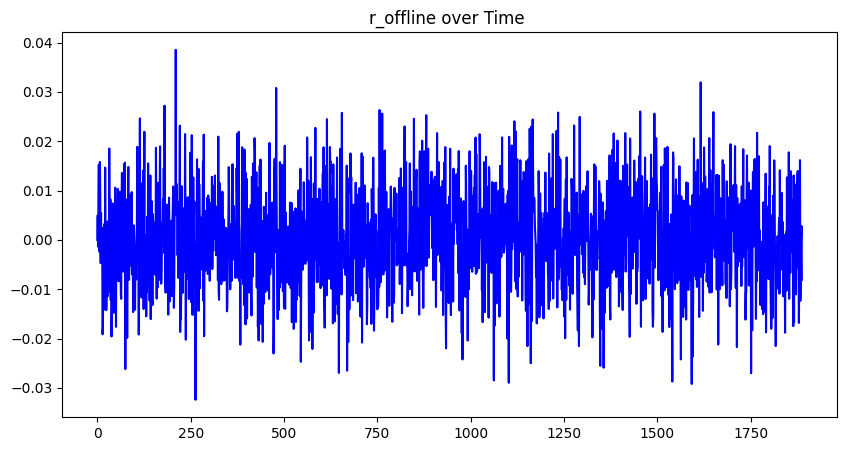

In [370]:
# lambda_lasso = 0.0084321399
lambda_lasso = 0.0088
beta_offline, r_offline, n_active = multivariate_CGL_offline_lasso(topics, 
                                                                   sigma, 
                                                                   kappa, 
                                                                   w, 
                                                                   rolling_window_size = 20, 
                                                                   lambda_lasso = lambda_lasso, 
                                                                   correct_with_tanh=True, 
                                                                   random_number=42,
                                                                   standardize=True)
print(f"Number active {n_active}")

# kappa_est, intercept_est, r2 = estimate_kappa_nls(topics, beta_offline, r_offline, w, correct_with_tanh=True, rolling_window_size=20)

# plot r_offline for the first run
plt.figure(figsize=(10, 5))
plt.plot(r_offline, label='r_offline', color='blue')
plt.title('r_offline over Time ')

In [371]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# 0. Identify topic names (assuming 'topics' is a DataFrame)
topic_names = topics.columns.tolist()
warnings.filterwarnings("ignore", category=ConvergenceWarning)
results_list = []

# Loop through random states
for seed in range(3):
    if seed % 1 == 0:
        print(f"Processing random_state {seed} out of 5...")
        
    # 1. Run the offline Lasso model
    beta_offline, r_offline, n_active = multivariate_CGL_offline_lasso(topics, sigma, kappa, w, rolling_window_size = 20, lambda_lasso =  lambda_lasso, correct_with_tanh=True, random_number=42)

    
    # Clean the beta matrix (handle nesting/singleton dimensions)
    beta_cleaned = np.squeeze(beta_offline)
    
    # 2. Convert the beta matrix into a named DataFrame
    beta_named_df = pd.DataFrame(beta_cleaned, columns=topic_names)
    
    # 3. Estimate the ALM parameters via NLS
    kappa_est, intercept_est, r2 = estimate_kappa_nls(
        topics, 
        beta_offline, 
        r_offline, 
        w, 
        correct_with_tanh=True, 
        rolling_window_size=20
    )
    
    # 4. Append the results
    results_list.append({
        'random_state': seed,
        'n_active_total': n_active,
        'kappa_est': kappa_est,
        'intercept_est': intercept_est,
        'r2_score': r2,
        # Now storing a named DataFrame instead of a raw array
        'beta_coefficients': beta_named_df, 
        'r_offline': r_offline.copy() 
    })

# 5. Convert to main results DataFrame
results_df = pd.DataFrame(results_list)

print("\nSimulation Complete!")

Processing random_state 0 out of 5...
Processing random_state 1 out of 5...
Processing random_state 2 out of 5...

Simulation Complete!


In [372]:
# Get Topic 1 (e.g., 'Natural disasters') from the first run
first_run_betas = results_df['beta_coefficients'].iloc[0]
natural_disasters_series = first_run_betas['Natural disasters']
print(f"Mean Beta for Natural disasters in Run 0: {natural_disasters_series.mean():.6f}")

Mean Beta for Natural disasters in Run 0: 0.000000


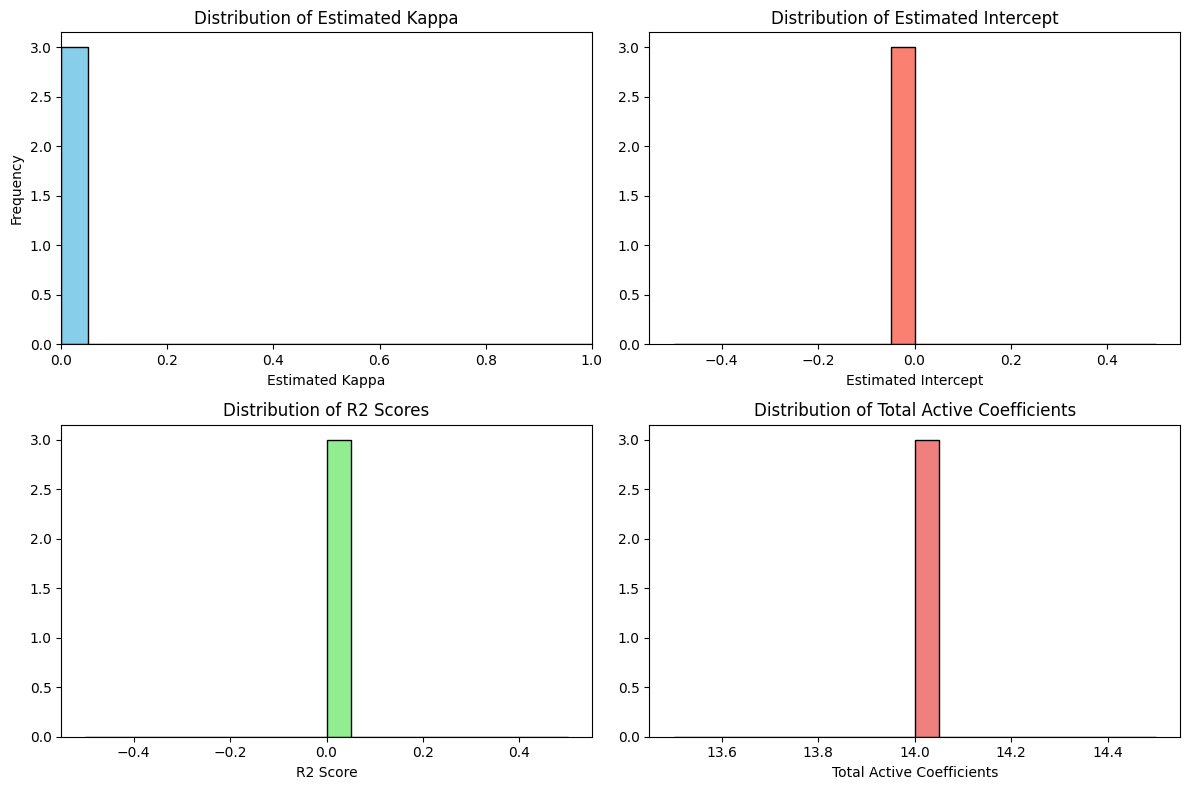

In [373]:
# plot the results
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(results_df['kappa_est'].dropna(), bins=20, range=(0, 1), color='skyblue', edgecolor='black')
plt.title('Distribution of Estimated Kappa')
plt.xlabel('Estimated Kappa')
plt.ylabel('Frequency')
# Set the x-axis limits strictly from 0 to 1
plt.xlim(0, 1)
plt.subplot(2, 2, 2)
plt.hist(results_df['intercept_est'].dropna(), bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Estimated Intercept')
plt.xlabel('Estimated Intercept')
plt.subplot(2, 2, 3)
plt.hist(results_df['r2_score'].dropna(), bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of R2 Scores')
plt.xlabel('R2 Score')
plt.subplot(2, 2, 4)
plt.hist(results_df['n_active_total'], bins=20, color='lightcoral', edgecolor='black')
plt.title('Distribution of Total Active Coefficients')
plt.xlabel('Total Active Coefficients')
plt.tight_layout()
plt.show()


In [374]:
import numpy as np
import pandas as pd

# 1. Convert the list of beta matrices into a 3D NumPy array
# Shape: (n_seeds, n_time_steps, n_topics)
beta_stack = np.array(results_df['beta_coefficients'].tolist())

# Clean up singleton dimensions if the Lasso output had a shape like (T, K, 1)
if beta_stack.ndim > 3:
    beta_stack = beta_stack.squeeze()

# 2. Calculate the count of non-zero occurrences across seeds
# We sum the boolean (beta != 0) along axis 0 (the random seeds axis)
selection_counts = (beta_stack != 0).sum(axis=0)

# 3. Organize into a DataFrame for easy inspection
# Rows = Time Steps, Columns = Topics
selection_counts_df = pd.DataFrame(
    selection_counts, 
    columns=[f'Topic_{i}' for i in range(selection_counts.shape[1])]
)

# 4. Optional: Add a 'Time_Step' index or column if you have dates
selection_counts_df.index.name = 'Time_Step'

# Display the result


# To see the total selection count across all time and all seeds for each topic:
print("\nTotal 'Active' instances across the entire period per topic:")
print(selection_counts_df.sum())

# out of all cells that are not 0, count the cells that are equal to 10
print("\nCount of cells that are exactly 10 (selected in all runs):")
print((selection_counts_df == 10).sum().sum())


Total 'Active' instances across the entire period per topic:
Topic_0      0
Topic_1      0
Topic_2      0
Topic_3      0
Topic_4      0
            ..
Topic_175    0
Topic_176    0
Topic_177    0
Topic_178    0
Topic_179    0
Length: 180, dtype: int64

Count of cells that are exactly 10 (selected in all runs):
0


C:\Users\jonat\AppData\Local\Temp\ipykernel_39848\759244814.py:16: RuntimeWarning: Mean of empty slice
  mean_beta_active = np.nanmean(beta_temp, axis=0)
c:\Users\jonat\anaconda3\envs\reddit_env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


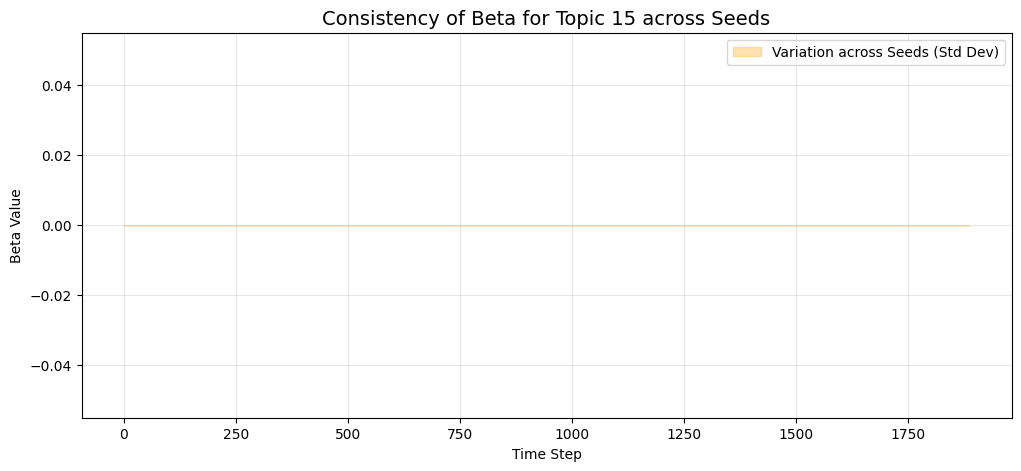

Max variation (Std Dev) for Topic 15: nan


C:\Users\jonat\AppData\Local\Temp\ipykernel_39848\759244814.py:56: RuntimeWarning: All-NaN slice encountered
  print(f"Max variation (Std Dev) for Topic {topic_idx}: {np.nanmax(y_std):.6f}")


In [375]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare and Squeeze the stack
beta_stack = np.array(results_df['beta_coefficients'].tolist())
# This removes any singleton dimensions (like the '1' in (20, T, K, 1))
beta_stack = np.squeeze(beta_stack)

# 2. Identify where topics were selected
# Replace zeros with NaN so they don't bias the Mean/Std Dev
beta_temp = beta_stack.copy().astype(float)
beta_temp[beta_temp == 0] = np.nan

# 3. Calculate Mean and Std across seeds (axis 0)
mean_beta_active = np.nanmean(beta_temp, axis=0)
std_beta_active = np.nanstd(beta_temp, axis=0)

# 4. Plotting for Topic 1
topic_idx = 15

# Extract the 1D arrays for the specific topic
# We use .flatten() just in case there are hidden dimensions
x = np.arange(mean_beta_active.shape[0])
y_mean = mean_beta_active[:, topic_idx].flatten()
y_std = std_beta_active[:, topic_idx].flatten()

# Fill NaNs with 0 for the plot so it doesn't break the line
y_mean_plot = np.nan_to_num(y_mean)
y_std_plot = np.nan_to_num(y_std)

plt.figure(figsize=(12, 5))

# Plot the mean line


# Plot the variation band (Std Dev)
# This will show you exactly if/how much the coefficient differs across runs
plt.fill_between(
    x, 
    y_mean_plot - y_std_plot, 
    y_mean_plot + y_std_plot, 
    alpha=0.3, 
    color='orange', 
    label='Variation across Seeds (Std Dev)'
)

plt.title(f'Consistency of Beta for Topic {topic_idx} across Seeds', fontsize=14)
plt.ylabel('Beta Value')
plt.xlabel('Time Step')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Quick check: 
print(f"Max variation (Std Dev) for Topic {topic_idx}: {np.nanmax(y_std):.6f}")

After simulating data, we feed the same data into our empirircal code.

------------------------------
RESULTS FOR RUN 0 (Random State: 0)
------------------------------
R² Score:          -0.000000
Kappa (Estimated): 0.000000
Intercept:         0.000449
Total Active:      14


Text(0.5, 1.0, 'r_offline over Time for Run 0')

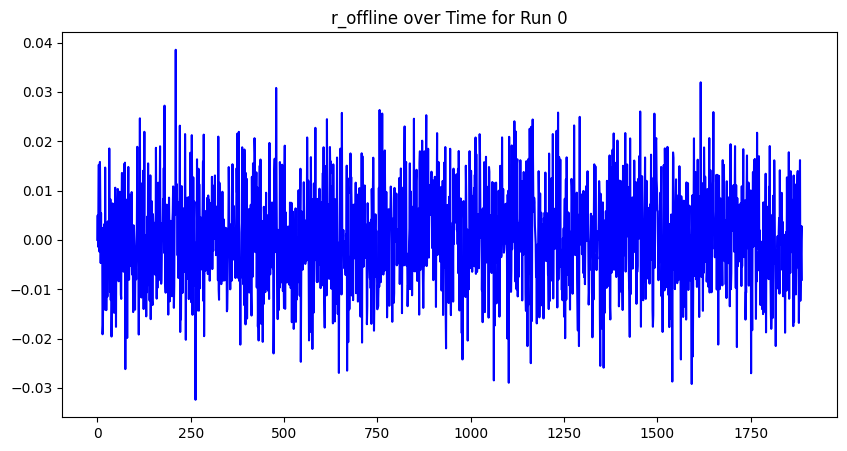

In [376]:
# 1. Extract the first row as a Series
first_run = results_df.iloc[0]
r_offline_0 = first_run['r_offline']


# 2. Print scalar metrics and parameters
print("-" * 30)
print(f"RESULTS FOR RUN 0 (Random State: {first_run['random_state']})")
print("-" * 30)
print(f"R² Score:          {first_run['r2_score']:.6f}")
print(f"Kappa (Estimated): {first_run['kappa_est']:.6f}")
print(f"Intercept:         {first_run['intercept_est']:.6f}")
print(f"Total Active:      {first_run['n_active_total']}")

# plot r_offline for the first run
plt.figure(figsize=(10, 5))
plt.plot(r_offline_0, label='r_offline (Run 0)', color='blue')
plt.title('r_offline over Time for Run 0')

In [377]:
results = estimate_single_config_fast(topics, r_offline_0, window_size = 20, n_lags = 1, lambda_val = lambda_lasso, standardize=True, verbose=False, save_only_positve_r_squared = False, return_details=True)

In [378]:
# get betas from empirical run
beta_columns = [col for col in results['details'].columns if col.startswith('Lasso_')]
betas_empirical = results['details'][beta_columns].values
betas_empirical = np.squeeze(betas_empirical)

Overall Correlation: 0.646277
--- Non-Zero Cell Analysis ---
Non-zero cells in Empirical: 14
Non-zero cells in Simulated: 14
Cells non-zero in BOTH:      6
Intersection over Union:     27.2727%
Total exactly matching cells: 336218 out of 336240
Empirical Topic 10: 0 non-zero cells out of 1868
Simulated Topic 10: 0 non-zero cells out of 1868


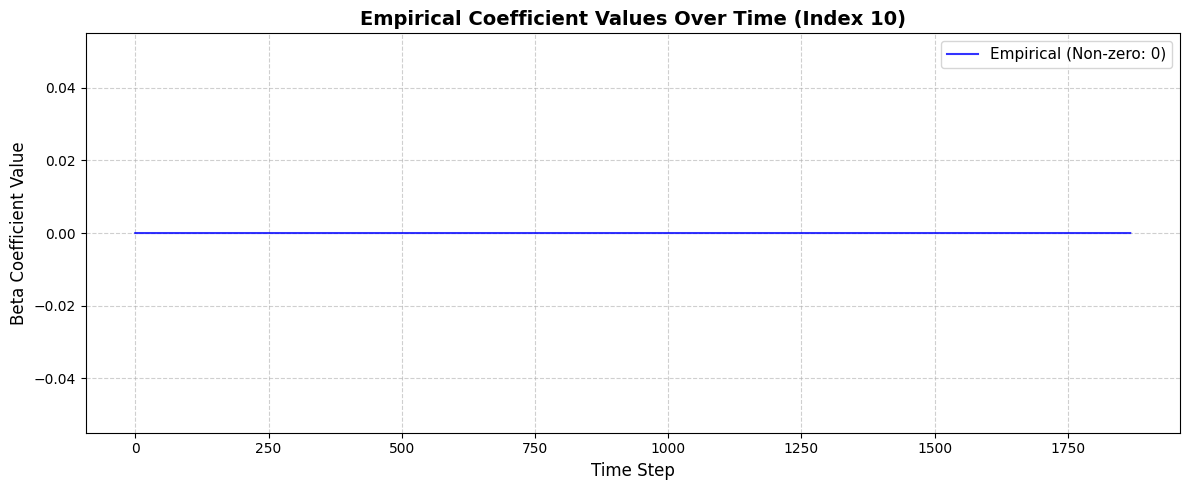

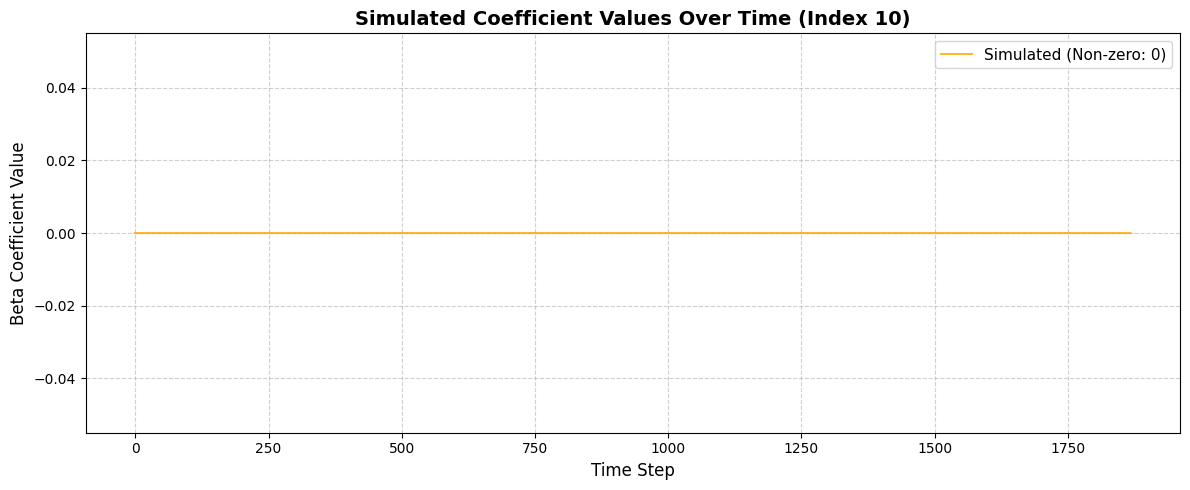

In [379]:
# 1. Extract the simulated betas from Run 0
# We use .iloc[0] and convert to NumPy to match the empirical data type
sim_betas_raw = results_df['beta_coefficients'].iloc[0].values 

# 2. Align Lengths (Trimming the simulated betas to match the empirical length)
# Assuming the empirical betas start after the first rolling window
if sim_betas_raw.shape[0] > betas_empirical.shape[0]:
    # Calculate the offset (should be 20)
    offset = sim_betas_raw.shape[0] - betas_empirical.shape[0]
    sim_betas_aligned = sim_betas_raw[offset:, :]
else:
    sim_betas_aligned = sim_betas_raw

# 3. Final Conversion and Shape Squeeze
# This ensures both are <class 'numpy.ndarray'> with shape (1868, 180)
sim_betas_final = np.ascontiguousarray(sim_betas_aligned)
emp_betas_final = np.ascontiguousarray(betas_empirical)

total_corr = np.corrcoef(emp_betas_final.flatten(), sim_betas_final.flatten())[0, 1]
print(f"Overall Correlation: {total_corr:.6f}")

# 1. Create masks for non-zero values in both arrays
mask_empirical = (emp_betas_final != 0)
mask_simulated = (sim_betas_final != 0)

# 2. Find cells where both masks are True (Logical AND)
both_nonzero = np.logical_and(mask_empirical, mask_simulated)

# 3. Calculate counts
count_emp = np.sum(mask_empirical)
count_sim = np.sum(mask_simulated)
count_overlap = np.sum(both_nonzero)

# 4. Calculate percentage of overlap (Jaccard-style)
union_nonzero = np.logical_or(mask_empirical, mask_simulated)
jaccard_similarity = count_overlap / np.sum(union_nonzero)

print(f"--- Non-Zero Cell Analysis ---")
print(f"Non-zero cells in Empirical: {count_emp}")
print(f"Non-zero cells in Simulated: {count_sim}")
print(f"Cells non-zero in BOTH:      {count_overlap}")
print(f"Intersection over Union:     {jaccard_similarity:.4%}")

# 5. Check for exact matches (including the specific coefficient values)
exact_matches = np.isclose(emp_betas_final, sim_betas_final, atol=1e-8)
print(f"Total exactly matching cells: {np.sum(exact_matches)} out of {emp_betas_final.size}")

# Topic index configuration
topic_idx = 10

# Extract the time series
emp_topic_10 = emp_betas_final[:, topic_idx]
sim_topic_10 = sim_betas_final[:, topic_idx]

# Calculation of non-zero cells
emp_nonzero = np.count_nonzero(emp_topic_10)
sim_nonzero = np.count_nonzero(sim_topic_10)
total_cells = len(emp_topic_10)

print(f"Empirical Topic 10: {emp_nonzero} non-zero cells out of {total_cells}")
print(f"Simulated Topic 10: {sim_nonzero} non-zero cells out of {total_cells}")

# --- Plot 1: Empirical Data ---
plt.figure(figsize=(12, 5))
plt.plot(emp_topic_10, label=f'Empirical (Non-zero: {emp_nonzero})', color='blue', alpha=0.8, linewidth=1.5)
plt.title(f'Empirical Coefficient Values Over Time (Index {topic_idx})', fontsize=14, fontweight='bold')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Beta Coefficient Value', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Plot 2: Simulated Data ---
plt.figure(figsize=(12, 5))
plt.plot(sim_topic_10, label=f'Simulated (Non-zero: {sim_nonzero})', color='orange', alpha=0.8, linewidth=1.5)
plt.title(f'Simulated Coefficient Values Over Time (Index {topic_idx})', fontsize=14, fontweight='bold')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Beta Coefficient Value', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [381]:
import pandas as pd

# Data structures to hold the results
records = []

# Loop through the first 10 topics
for i in range(180):
    # Find indices where values are non-zero
    emp_nonzero_indices = np.where(emp_betas_final[:, i] != 0)[0]
    sim_nonzero_indices = np.where(sim_betas_final[:, i] != 0)[0]
    
    # Create a summary string of the first 5 dates for display
    emp_sample = ", ".join(map(str, emp_nonzero_indices[:5])) + ("..." if len(emp_nonzero_indices) > 5 else "")
    sim_sample = ", ".join(map(str, sim_nonzero_indices[:5])) + ("..." if len(sim_nonzero_indices) > 5 else "")
    
    records.append({
        "Topic Index": i,
        "Empirical Total Active": len(emp_nonzero_indices),
        "Empirical First Dates": emp_sample,
        "Simulated Total Active": len(sim_nonzero_indices),
        "Simulated First Dates": sim_sample
    })

# Create DataFrame
nonzero_table = pd.DataFrame(records)

# Display the table
print("--- Comparison of Non-Zero Coefficient Occurrences (First 10 Topics) ---")
# loop and print each row with better formatting
for idx, row in nonzero_table.iterrows():
    print(f"Topic {row['Topic Index']}: Empirical Active={row['Empirical Total Active']} (Dates: {row['Empirical First Dates']}), "
          f"Simulated Active={row['Simulated Total Active']} (Dates: {row['Simulated First Dates']})")

--- Comparison of Non-Zero Coefficient Occurrences (First 10 Topics) ---
Topic 0: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 1: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 2: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 3: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 4: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 5: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 6: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 7: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 8: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 9: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 10: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 11: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 12: Empirical Active=0 (Dates: ), Simulated Active=0 (Dates: )
Topic 13: Empirical Active=0 (Dates: ), 